# OrthoIQ: Surgical Likelihood Analytics
*Ryan Collins MAT, ATC*



### Synthetic Orthopedic Healthcare Analytics Project

## Project Overview

OrthoIQ is an orthopedic healthcare analytics project designed to explore factors associated with surgical treatment and evaluate whether patient characteristics can be used to estimate surgical likelihood.

The project begins with a synthetic general healthcare dataset and isolates patients diagnosed with arthritis. Because the source dataset does not contain detailed orthopedic clinical variables or surgical outcomes, additional orthopedic features and surgical outcomes will be synthetically generated for educational and portfolio modeling purposes.

The synthetic variables are intended to create a realistic analytical environment for demonstrating healthcare data analysis and machine-learning techniques. They should not be interpreted as real patient observations, validated surgical criteria, or a clinical decision-making tool.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare_dataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [2]:
# Remove exact duplicate records
df = df.drop_duplicates().copy()

# Create arthritis cohort
arthritis_df = df[df["Medical Condition"] == "Arthritis"].copy()

print("Cleaned dataset:", df.shape)
print("Arthritis cohort:", arthritis_df.shape)
print(
    "Arthritis percentage:",
    round(len(arthritis_df) / len(df) * 100, 2),
    "%"
)

Cleaned dataset: (54966, 15)
Arthritis cohort: (9218, 15)
Arthritis percentage: 16.77 %


## Arthritis Cohort

This analysis focuses on patients diagnosed with arthritis because arthritis represents the primary musculoskeletal condition available in the source dataset.

Exact duplicate records were removed before cohort selection. The arthritis population serves as the foundation for the synthetic orthopedic extension of OrthoIQ.

## Synthetic Orthopedic Data Augmentation

The original healthcare dataset does not contain detailed orthopedic examination findings, imaging severity, conservative treatment history, or surgical outcomes.

To create an orthopedic-focused machine-learning project, additional clinical variables were synthetically generated for the arthritis cohort. The synthetic variables were designed to create plausible relationships between patient characteristics while preserving randomness and variability between patients.

These variables are simulated for educational purposes and do not represent real patient observations or validated surgical decision criteria.

In [3]:
# Set seed so synthetic results are reproducible
np.random.seed(42)

n = len(arthritis_df)

# BMI
arthritis_df["BMI"] = np.random.normal(
    loc=29,
    scale=5,
    size=n
).clip(18, 50).round(1)

# Comorbidity Count
arthritis_df["Comorbidity Count"] = np.random.poisson(
    lam=1.5,
    size=n
).clip(0, 5)

### Modeling Clinical Relationships

To create a more realistic synthetic orthopedic population, related clinical variables were generated using an underlying simulated arthritis severity score.

Imaging severity, functional limitation, and pain score were designed to share a common relationship with underlying disease severity while retaining patient-level variability. This allows clinically related characteristics to move in similar directions without requiring them to match perfectly.

BMI and comorbidity burden were generated separately because they represent patient characteristics rather than direct measures of arthritis severity.

In [4]:
arthritis_df = arthritis_df.reset_index(drop=True)

np.random.seed(42)

n = len(arthritis_df)

In [5]:
arthritis_df["Underlying Severity"] = np.random.normal(
    loc=0,
    scale=1,
    size=n
)

In [6]:
imaging_score = (
    1.2 * arthritis_df["Underlying Severity"]
    + np.random.normal(0, 0.6, n)
)

arthritis_df["Imaging Severity"] = pd.cut(
    imaging_score,
    bins=[-np.inf, -0.6, 0.6, np.inf],
    labels=["Mild", "Moderate", "Severe"]
)

In [7]:
function_score = (
    1.1 * arthritis_df["Underlying Severity"]
    + np.random.normal(0, 0.8, n)
)

arthritis_df["Functional Limitation"] = pd.cut(
    function_score,
    bins=[-np.inf, -0.6, 0.6, np.inf],
    labels=["Mild", "Moderate", "Severe"]
)

In [8]:
pain_continuous = (
    6
    + 1.5 * arthritis_df["Underlying Severity"]
    + np.random.normal(0, 1.3, n)
)

arthritis_df["Pain Score"] = (
    pain_continuous
    .round()
    .clip(0, 10)
    .astype(int)
)

In [9]:
clinical_relationships = pd.crosstab(
    arthritis_df["Imaging Severity"],
    arthritis_df["Functional Limitation"],
    normalize="index"
).mul(100).round(1)

clinical_relationships

Functional Limitation,Mild,Moderate,Severe
Imaging Severity,,,
Mild,67.0,27.9,5.1
Moderate,27.7,46.9,25.4
Severe,5.5,27.3,67.2


In [10]:
pain_by_imaging = (
    arthritis_df
    .groupby(
        "Imaging Severity",
        observed=False
    )["Pain Score"]
    .agg(["count", "mean", "median"])
    .round(2)
)

pain_by_imaging

,count,mean,median
Imaging Severity,,,
Mild,3029,4.50,4.0
Moderate,3131,5.96,6.0
Severe,3058,7.40,7.0


### Conservative Treatment Progression

Conservative treatment history was simulated separately from disease severity because treatment progression is not determined by imaging findings alone.

Patients with greater disease severity and higher pain levels were assigned a higher probability of progressing through conservative management. However, random variation was retained because patients with similar clinical presentations may be at different stages of nonsurgical treatment.

Failed conservative treatment represents patients who have undergone appropriate nonsurgical management, such as physical therapy, corticosteroid injections, and/or viscosupplementation, without adequate improvement.

In [11]:
# Create a synthetic conservative treatment progression score

treatment_score = (
    0.7 * arthritis_df["Underlying Severity"]
    + 0.15 * (arthritis_df["Pain Score"] - 6)
    + np.random.normal(0, 1.0, n)
)

arthritis_df["Conservative Treatment"] = pd.cut(
    treatment_score,
    bins=[-np.inf, -0.6, 0.6, np.inf],
    labels=["Not Attempted", "In Progress", "Failed"]
)

In [12]:
treatment_by_imaging = pd.crosstab(
    arthritis_df["Imaging Severity"],
    arthritis_df["Conservative Treatment"],
    normalize="index"
).mul(100).round(1)

treatment_by_imaging

Conservative Treatment,Not Attempted,In Progress,Failed
Imaging Severity,,,
Mild,60.2,29.4,10.4
Moderate,28.9,41.1,30.0
Severe,10.1,29.2,60.7


In [13]:
treatment_by_function = pd.crosstab(
    arthritis_df["Functional Limitation"],
    arthritis_df["Conservative Treatment"],
    normalize="index"
).mul(100).round(1)

treatment_by_function

Conservative Treatment,Not Attempted,In Progress,Failed
Functional Limitation,,,
Mild,57.6,30.0,12.4
Moderate,28.9,40.3,30.8
Severe,12.1,29.4,58.6


In [14]:
synthetic_features = [
    "Age",
    "BMI",
    "Pain Score",
    "Functional Limitation",
    "Imaging Severity",
    "Conservative Treatment",
    "Comorbidity Count"
]

arthritis_df[synthetic_features].head(10)

,Age,BMI,Pain Score,Functional Limitation,Imaging Severity,Conservative Treatment,Comorbidity Count
0,63,31.5,5,Severe,Moderate,In Progress,1
1,58,28.3,4,Moderate,Moderate,Not Attempted,1
2,23,32.2,6,Severe,Severe,In Progress,1
3,78,36.6,6,Severe,Severe,Failed,0
4,19,27.8,8,Mild,Moderate,In Progress,0
5,57,27.8,3,Moderate,Mild,Failed,1
6,74,36.9,8,Severe,Severe,Failed,1
7,22,32.8,7,Severe,Severe,In Progress,0
8,57,26.7,4,Mild,Mild,Not Attempted,1
9,20,31.7,7,Severe,Moderate,Failed,2


In [15]:
arthritis_df[
    [
        "BMI",
        "Pain Score",
        "Comorbidity Count"
    ]
].describe().round(2)

,BMI,Pain Score,Comorbidity Count
count,9218.00,9218.00,9218.00
mean,29.03,5.96,1.51
std,4.97,1.98,1.21
min,18.00,0.00,0.00
25%,25.60,5.00,1.00
50%,29.00,6.00,1.00
75%,32.40,7.00,2.00
max,48.60,10.00,5.00


## Synthetic Surgical Likelihood Target

A synthetic surgical outcome was generated using a probabilistic scoring model based on clinical factors selected for the orthopedic simulation.

Functional limitation, imaging severity, and failed conservative treatment were assigned the strongest positive influence on surgical likelihood. Age and pain score were given smaller positive effects.

BMI and comorbidity burden were modeled primarily as candidacy modifiers. Higher values can reduce the probability that a patient proceeds to surgery even when clinical severity is high.

The resulting surgical outcome is synthetic and is intended only for educational machine-learning analysis. It does not represent validated surgical criteria or clinical recommendations.

In [16]:
# Convert clinical categories into numeric scores

function_map = {
    "Mild": 0,
    "Moderate": 1,
    "Severe": 2
}

imaging_map = {
    "Mild": 0,
    "Moderate": 1,
    "Severe": 2
}

treatment_map = {
    "Not Attempted": 0,
    "In Progress": 1,
    "Failed": 2
}

arthritis_df["Function Score"] = (
    arthritis_df["Functional Limitation"]
    .map(function_map)
    .astype(int)
)

arthritis_df["Imaging Score"] = (
    arthritis_df["Imaging Severity"]
    .map(imaging_map)
    .astype(int)
)

arthritis_df["Treatment Score"] = (
    arthritis_df["Conservative Treatment"]
    .map(treatment_map)
    .astype(int)
)

In [17]:
# Synthetic surgical likelihood score

surgery_score = (
    -5.0

    # Strongest clinical factors
    + 1.35 * arthritis_df["Function Score"]
    + 1.20 * arthritis_df["Imaging Score"]
    + 1.15 * arthritis_df["Treatment Score"]

    # Moderate clinical factors
    + 0.018 * (arthritis_df["Age"] - 50)
    + 0.15 * (arthritis_df["Pain Score"] - 5)

    # Surgical candidacy modifiers
    - 0.04 * np.maximum(arthritis_df["BMI"] - 35, 0)
    - 0.12 * arthritis_df["Comorbidity Count"]

    # Random patient-level variation
    + np.random.normal(0, 0.65, len(arthritis_df))
)

In [18]:
arthritis_df["Surgery Probability"] = (
    1 / (1 + np.exp(-surgery_score))
)

In [19]:
arthritis_df["Surgery"] = np.random.binomial(
    n=1,
    p=arthritis_df["Surgery Probability"]
)

In [20]:
arthritis_df[
    [
        "Age",
        "BMI",
        "Pain Score",
        "Functional Limitation",
        "Imaging Severity",
        "Conservative Treatment",
        "Comorbidity Count",
        "Surgery Probability",
        "Surgery"
    ]
].head(15)

,Age,BMI,Pain Score,Functional Limitation,Imaging Severity,Conservative Treatment,Comorbidity Count,Surgery Probability,Surgery
0,63,31.5,5,Severe,Moderate,In Progress,1,0.418495,0
1,58,28.3,4,Moderate,Moderate,Not Attempted,1,0.117512,0
2,23,32.2,6,Severe,Severe,In Progress,1,0.755323,1
3,78,36.6,6,Severe,Severe,Failed,0,0.958949,1
4,19,27.8,8,Mild,Moderate,In Progress,0,0.111730,0
5,57,27.8,3,Moderate,Mild,Failed,1,0.186497,0
6,74,36.9,8,Severe,Severe,Failed,1,0.960918,1
7,22,32.8,7,Severe,Severe,In Progress,0,0.724727,1
8,57,26.7,4,Mild,Mild,Not Attempted,1,0.003649,0
9,20,31.7,7,Severe,Moderate,Failed,2,0.563621,1


In [21]:
surgery_counts = arthritis_df["Surgery"].value_counts()

surgery_percent = (
    arthritis_df["Surgery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("Surgery Counts:")
print(surgery_counts)

print("\nSurgery Percentages:")
print(surgery_percent)

Surgery Counts:
Surgery
0    5868
1    3350
Name: count, dtype: int64

Surgery Percentages:
Surgery
0    63.7
1    36.3
Name: proportion, dtype: float64


In [22]:
surgery_by_function = pd.crosstab(
    arthritis_df["Functional Limitation"],
    arthritis_df["Surgery"],
    normalize="index"
).mul(100).round(1)

surgery_by_function.columns = ["No Surgery", "Surgery"]

surgery_by_function

,No Surgery,Surgery
Functional Limitation,,
Mild,95.4,4.6
Moderate,69.4,30.6
Severe,25.2,74.8


In [23]:
surgery_by_imaging = pd.crosstab(
    arthritis_df["Imaging Severity"],
    arthritis_df["Surgery"],
    normalize="index"
).mul(100).round(1)

surgery_by_imaging.columns = ["No Surgery", "Surgery"]

surgery_by_imagingsurgery_by_imaging = pd.crosstab(
    arthritis_df["Imaging Severity"],
    arthritis_df["Surgery"],
    normalize="index"
).mul(100).round(1)

surgery_by_imaging.columns = ["No Surgery", "Surgery"]

surgery_by_imaging

,No Surgery,Surgery
Imaging Severity,,
Mild,95.8,4.2
Moderate,69.8,30.2
Severe,25.5,74.5


In [24]:
arthritis_df["Surgery"].value_counts(normalize=True).mul(100).round(1)

,proportion
Surgery,
0,63.7
1,36.3


## Surgical Likelihood Prediction

The next phase of OrthoIQ evaluates whether patient characteristics can be used to classify the synthetic surgical outcome.

The prediction task is structured as a binary classification problem:

- **0 = No Surgery**
- **1 = Surgery**

Only patient characteristics available prior to the simulated surgical decision are included as predictors.

Because the surgical outcome itself was synthetically generated, model performance should be interpreted as the model's ability to recover patterns within the simulation rather than evidence of real-world clinical predictive performance.

In [25]:
features = [
    "Age",
    "BMI",
    "Pain Score",
    "Functional Limitation",
    "Imaging Severity",
    "Conservative Treatment",
    "Comorbidity Count"
]

X = arthritis_df[features].copy()
y = arthritis_df["Surgery"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (9218, 7)
Target shape: (9218,)


,Age,BMI,Pain Score,Functional Limitation,Imaging Severity,Conservative Treatment,Comorbidity Count
0,63,31.5,5,Severe,Moderate,In Progress,1
1,58,28.3,4,Moderate,Moderate,Not Attempted,1
2,23,32.2,6,Severe,Severe,In Progress,1
3,78,36.6,6,Severe,Severe,Failed,0
4,19,27.8,8,Mild,Moderate,In Progress,0


In [26]:
X.dtypes

,0
Age,int64
BMI,float64
Pain Score,int64
Functional Limitation,category
Imaging Severity,category
Conservative Treatment,category
Comorbidity Count,int64


In [27]:
numeric_features = [
    "Age",
    "BMI",
    "Pain Score",
    "Comorbidity Count"
]

categorical_features = [
    "Functional Limitation",
    "Imaging Severity",
    "Conservative Treatment"
]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(1))

Training rows: 7374
Testing rows: 1844

Training target distribution:
Surgery
0    63.7
1    36.3
Name: proportion, dtype: float64

Testing target distribution:
Surgery
0    63.7
1    36.3
Name: proportion, dtype: float64


In [29]:
from sklearn.metrics import accuracy_score

baseline_predictions = np.zeros(len(y_test), dtype=int)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline Accuracy:",
    round(baseline_accuracy, 3)
)

Baseline Accuracy: 0.637


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [31]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BMI', 'Pain Score',
                                                   'Comorbidity Count']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Functional Limitation',
                                                   'Imaging Severity',
                                                   'Conservative '
                                                   'Treatment'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [32]:
y_pred_logistic = logistic_model.predict(X_test)


In [33]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy, 3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_logistic
    )
)

Logistic Regression Accuracy: 0.858

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1174
           1       0.80      0.80      0.80       670

    accuracy                           0.86      1844
   macro avg       0.85      0.85      0.85      1844
weighted avg       0.86      0.86      0.86      1844


Confusion Matrix:
[[1043  131]
 [ 131  539]]


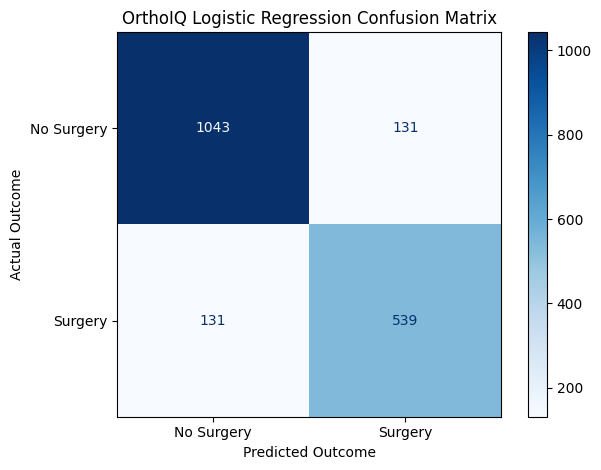

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Visualize Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["No Surgery", "Surgery"],
    cmap="Blues",
    values_format="d"
)

plt.title("OrthoIQ Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()
plt.show()

## Logistic Regression Feature Interpretation

Logistic Regression coefficients were examined to better understand how individual patient characteristics influenced the model's prediction of the synthetic surgical outcome.

Positive coefficients move the model toward predicting surgery, while negative coefficients move the model toward predicting no surgery.

Because several clinical predictors are correlated and the categorical variables are one-hot encoded, coefficients should be interpreted as indicators of model behavior rather than definitive measures of clinical importance.

In [35]:
# Get feature names created by preprocessing
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get Logistic Regression coefficients
coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
5,cat__Functional Limitation_Severe,2.575448
7,cat__Imaging Severity_Severe,2.227075
4,cat__Functional Limitation_Moderate,1.387460
6,cat__Imaging Severity_Moderate,1.240457
2,num__Pain Score,0.393192
0,num__Age,0.335915
1,num__BMI,-0.057379
3,num__Comorbidity Count,-0.167529
8,cat__Conservative Treatment_In Progress,-0.949111
9,cat__Conservative Treatment_Not Attempted,-2.019588


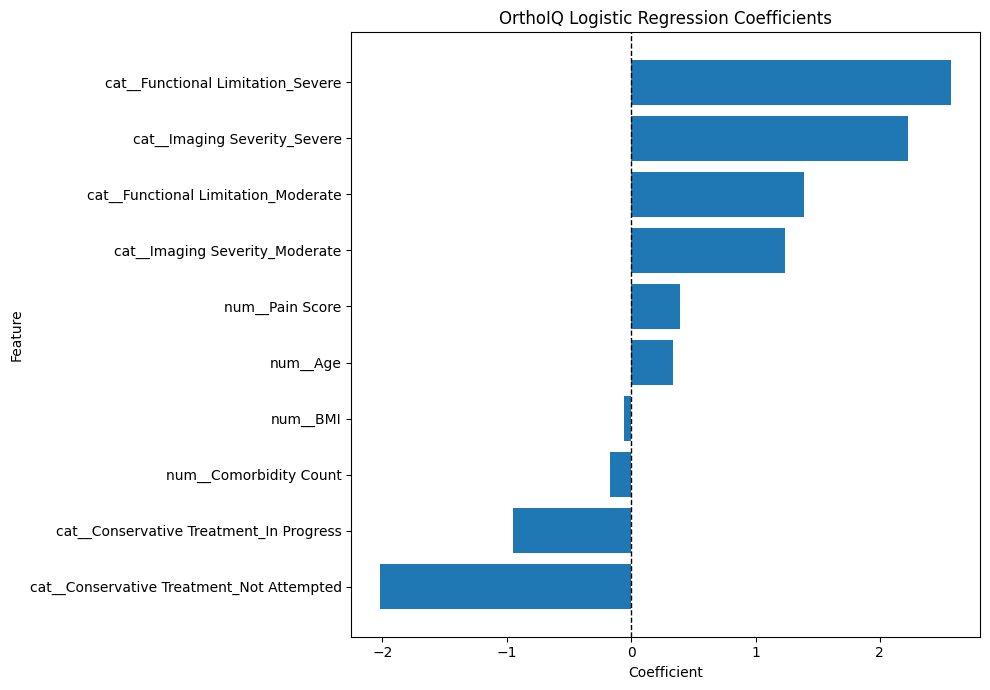

In [36]:
# Visualize Logistic Regression coefficients

plot_df = coef_df.sort_values(
    by="Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("OrthoIQ Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Coefficient Interpretation

The Logistic Regression coefficients generally recovered the relationships intentionally embedded within the synthetic orthopedic population.

Severe functional limitation and severe imaging findings produced the strongest positive coefficients, followed by moderate functional limitation and moderate imaging severity. Higher pain scores and older age also moved predictions toward the synthetic surgery outcome.

BMI and comorbidity count had relatively small negative coefficients, which is consistent with their intended role as surgical-candidacy modifiers rather than primary indicators for surgery.

For conservative treatment, **Failed** serves as the reference category because of the one-hot encoding strategy. Therefore, the negative coefficients for **In Progress** and **Not Attempted** indicate lower predicted surgical likelihood relative to patients who had failed conservative management.

Because these clinical predictors were synthetically generated and several are correlated, the coefficients describe model behavior within the simulation and should not be interpreted as real-world causal effects or validated clinical importance.

## Comparison Model: Random Forest

A Random Forest classifier was trained as a comparison to Logistic Regression.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions between patient characteristics without assuming a linear relationship between each predictor and the surgical outcome.

Model performance will be compared using accuracy, precision, recall, F1-score, and the confusion matrix.

In [37]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BMI', 'Pain Score',
                                                   'Comorbidity Count']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Functional Limitation',
                                                   'Imaging Severity',
                                                   'Conservative '
                                                   'Treatment'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [38]:
y_pred_rf = random_forest_model.predict(X_test)

In [39]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy, 3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

Random Forest Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1174
           1       0.77      0.76      0.77       670

    accuracy                           0.83      1844
   macro avg       0.82      0.82      0.82      1844
weighted avg       0.83      0.83      0.83      1844


Confusion Matrix:
[[1021  153]
 [ 160  510]]


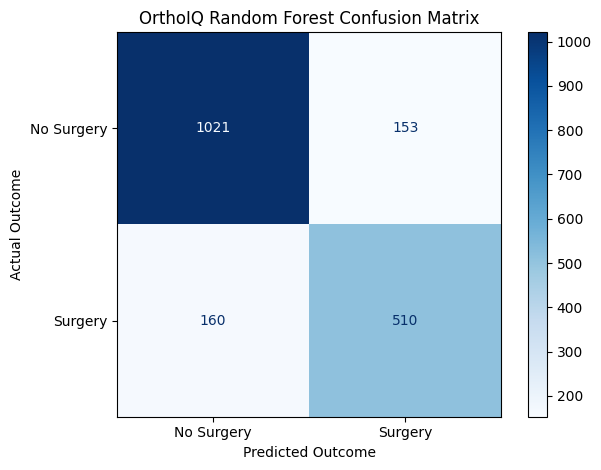

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Surgery", "Surgery"],
    cmap="Blues",
    values_format="d"
)

plt.title("OrthoIQ Random Forest Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()
plt.show()

## Model Comparison

Logistic Regression and Random Forest were compared using the same training and testing populations.

Performance was evaluated using overall accuracy as well as precision, recall, and F1-score for the surgical outcome. Because the project focuses on identifying patients with a higher likelihood of surgery, recall for the surgery class is particularly important.

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Surgery Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    "Surgery Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    "Surgery F1": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ]
})

model_comparison.round(3)

,Model,Accuracy,Surgery Precision,Surgery Recall,Surgery F1
0,Logistic Regression,0.858,0.804,0.804,0.804
1,Random Forest,0.830,0.769,0.761,0.765


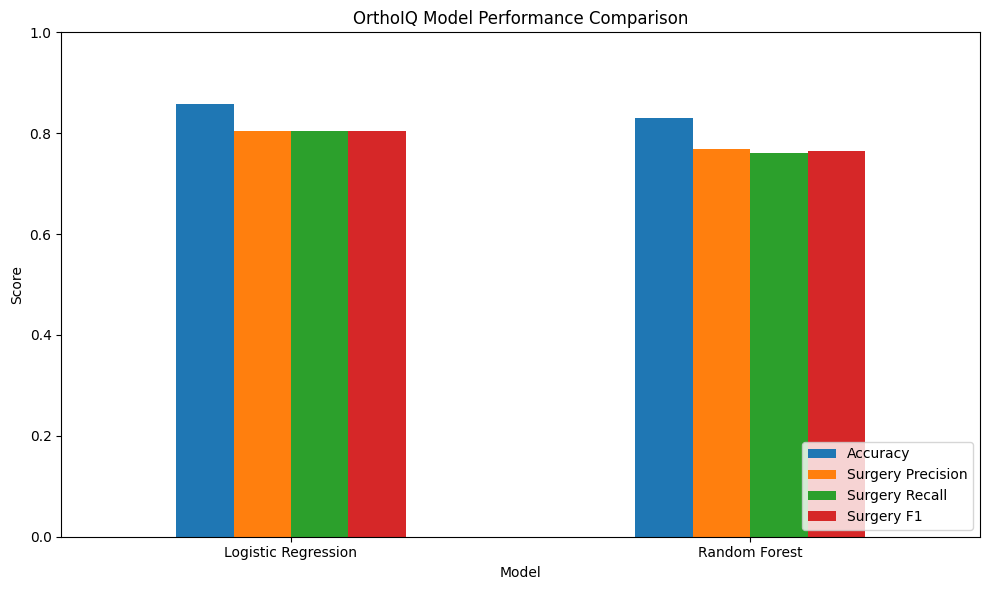

In [42]:
comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("OrthoIQ Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## ROC-AUC and Predicted Surgical Probability

In addition to binary classifications, the models can estimate the probability that a patient belongs to the synthetic surgery class.

ROC-AUC evaluates how well a model distinguishes between patients with and without the synthetic surgical outcome across different classification thresholds.

An ROC-AUC of 0.50 represents performance similar to random classification, while values closer to 1.00 indicate stronger discrimination.

Because the surgical outcome in OrthoIQ is synthetically generated, these probabilities represent model estimates within the simulation and should not be interpreted as validated clinical risk estimates.

In [43]:
from sklearn.metrics import roc_auc_score

# Predicted probability of Surgery (class 1)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

# ROC-AUC
logistic_auc = roc_auc_score(y_test, logistic_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

print(
    "Logistic Regression ROC-AUC:",
    round(logistic_auc, 3)
)

print(
    "Random Forest ROC-AUC:",
    round(rf_auc, 3)
)

Logistic Regression ROC-AUC: 0.936
Random Forest ROC-AUC: 0.913


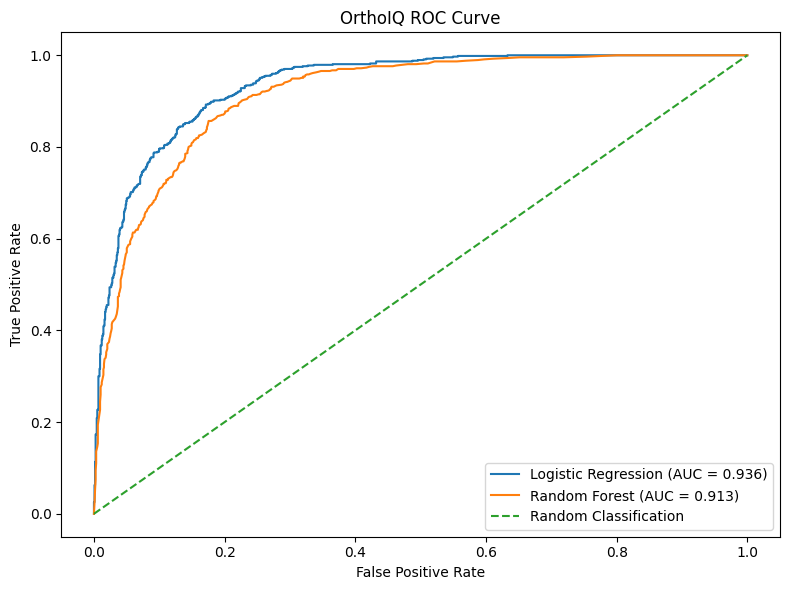

In [44]:
from sklearn.metrics import roc_curve

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classification"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("OrthoIQ ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

## Patient-Level Surgical Likelihood

The preferred Logistic Regression model was used to generate patient-level probabilities for the synthetic surgical outcome.

Rather than displaying only a binary Surgery or No Surgery classification, predicted probabilities provide a continuous estimate of surgical likelihood within the simulated OrthoIQ environment.

These probabilities are generated from synthetic data and should not be interpreted as validated clinical risk estimates or recommendations for surgery.

In [45]:
orthoiq_results = X_test.copy()

orthoiq_results["Actual Outcome"] = y_test.values
orthoiq_results["Predicted Outcome"] = y_pred_logistic
orthoiq_results["Surgical Likelihood"] = logistic_prob

orthoiq_results["Surgical Likelihood (%)"] = (
    orthoiq_results["Surgical Likelihood"] * 100
).round(1)

orthoiq_results[
    [
        "Age",
        "BMI",
        "Pain Score",
        "Functional Limitation",
        "Imaging Severity",
        "Conservative Treatment",
        "Comorbidity Count",
        "Surgical Likelihood (%)",
        "Predicted Outcome",
        "Actual Outcome"
    ]
].head(15)

,Age,BMI,Pain Score,Functional Limitation,Imaging Severity,Conservative Treatment,Comorbidity Count,Surgical Likelihood (%),Predicted Outcome,Actual Outcome
627,82,28.4,6,Mild,Moderate,In Progress,2,12.0,0,0
1674,56,37.1,8,Moderate,Severe,Failed,0,81.1,1,1
5585,48,25.4,3,Mild,Mild,Not Attempted,3,0.4,0,0
1037,32,21.7,4,Mild,Mild,Not Attempted,2,0.4,0,0
4686,27,25.0,5,Mild,Mild,Not Attempted,4,0.3,0,0
9051,49,23.4,4,Mild,Mild,In Progress,2,1.6,0,0
8994,82,28.9,5,Mild,Moderate,Not Attempted,0,4.8,0,0
2470,19,34.4,9,Severe,Severe,In Progress,0,78.4,1,1
6345,38,29.4,7,Moderate,Mild,Not Attempted,2,3.0,0,0
962,21,30.0,4,Mild,Mild,Not Attempted,1,0.4,0,0


In [46]:
orthoiq_results.sort_values(
    "Surgical Likelihood",
    ascending=False
)[
    [
        "Age",
        "BMI",
        "Pain Score",
        "Functional Limitation",
        "Imaging Severity",
        "Conservative Treatment",
        "Comorbidity Count",
        "Surgical Likelihood (%)",
        "Actual Outcome"
    ]
].head(10)

,Age,BMI,Pain Score,Functional Limitation,Imaging Severity,Conservative Treatment,Comorbidity Count,Surgical Likelihood (%),Actual Outcome
3602,82,39.2,10,Severe,Severe,Failed,0,97.0,1
1924,82,39.4,10,Severe,Severe,Failed,0,96.9,1
4818,81,32.1,10,Severe,Severe,Failed,1,96.7,1
1331,85,35.1,9,Severe,Severe,Failed,0,96.6,1
4262,78,32.8,10,Severe,Severe,Failed,1,96.5,1
6235,78,33.8,10,Severe,Severe,Failed,1,96.5,1
2838,79,40.1,10,Severe,Severe,Failed,1,96.3,1
6729,81,37.9,9,Severe,Severe,Failed,0,96.3,1
3236,82,34.0,10,Severe,Severe,Failed,2,96.2,1
6380,75,39.3,10,Severe,Severe,Failed,1,96.1,1


In [47]:
orthoiq_results.sort_values(
    "Surgical Likelihood",
    ascending=True
)[
    [
        "Age",
        "BMI",
        "Pain Score",
        "Functional Limitation",
        "Imaging Severity",
        "Conservative Treatment",
        "Comorbidity Count",
        "Surgical Likelihood (%)",
        "Actual Outcome"
    ]
].head(10)

,Age,BMI,Pain Score,Functional Limitation,Imaging Severity,Conservative Treatment,Comorbidity Count,Surgical Likelihood (%),Actual Outcome
5316,21,21.4,0,Mild,Mild,Not Attempted,2,0.2,0
607,30,22.8,2,Mild,Mild,Not Attempted,5,0.2,0
4431,27,18.0,1,Mild,Mild,Not Attempted,3,0.2,0
1194,27,21.0,2,Mild,Mild,Not Attempted,4,0.2,0
3282,21,18.2,1,Mild,Mild,Not Attempted,2,0.2,0
8200,24,18.0,1,Mild,Mild,Not Attempted,2,0.2,0
4027,26,27.7,3,Mild,Mild,Not Attempted,4,0.2,0
5358,20,20.0,1,Mild,Mild,Not Attempted,1,0.2,0
7218,29,23.4,3,Mild,Mild,Not Attempted,4,0.2,0
6482,24,24.6,3,Mild,Mild,Not Attempted,3,0.2,0


## Classification Threshold Analysis

The default classification threshold for Logistic Regression is 0.50. Patients with predicted probabilities of at least 50% are classified as Surgery, while those below 50% are classified as No Surgery.

In a hypothetical screening or triage setting, false negatives may be more consequential because they represent patients with a synthetic surgical outcome who were not identified by the model.

Lower classification thresholds were therefore explored to evaluate the tradeoff between increasing surgery recall and generating additional false-positive classifications.

This analysis is educational and based entirely on synthetic outcomes. It should not be interpreted as establishing an appropriate clinical decision threshold.

In [48]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        logistic_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        threshold_pred
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            threshold_pred
        ),
        "Surgery Precision": precision_score(
            y_test,
            threshold_pred
        ),
        "Surgery Recall": recall_score(
            y_test,
            threshold_pred
        ),
        "Surgery F1": f1_score(
            y_test,
            threshold_pred
        ),
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(3)

,Threshold,Accuracy,Surgery Precision,Surgery Recall,Surgery F1,False Positives,False Negatives
0,0.3,0.836,0.716,0.907,0.801,241,62
1,0.4,0.851,0.759,0.866,0.809,184,90
2,0.5,0.858,0.804,0.804,0.804,131,131
3,0.6,0.860,0.850,0.746,0.795,88,170
4,0.7,0.845,0.890,0.655,0.755,54,231


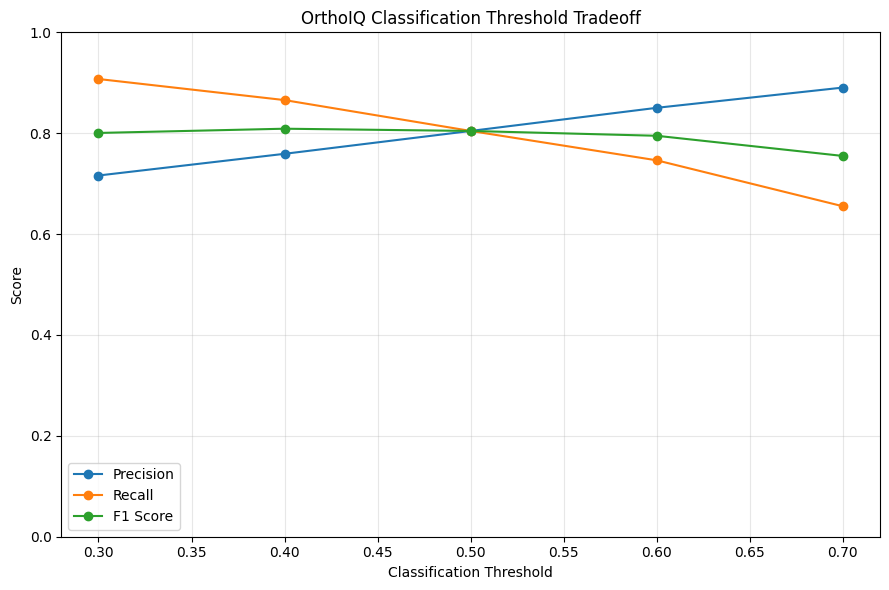

In [49]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Surgery Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Surgery Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Surgery F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("OrthoIQ Classification Threshold Tradeoff")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1174
           1       0.76      0.87      0.81       670

    accuracy                           0.85      1844
   macro avg       0.84      0.85      0.84      1844
weighted avg       0.86      0.85      0.85      1844



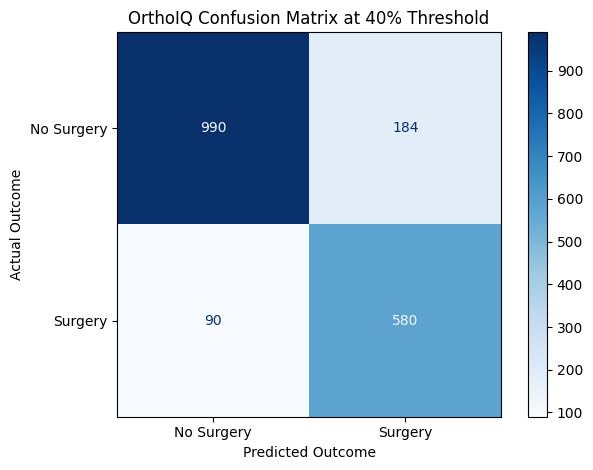

In [50]:
orthoiq_threshold = 0.40

orthoiq_predictions = (
    logistic_prob >= orthoiq_threshold
).astype(int)

print(
    classification_report(
        y_test,
        orthoiq_predictions
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    orthoiq_predictions,
    display_labels=["No Surgery", "Surgery"],
    cmap="Blues",
    values_format="d"
)

plt.title(
    "OrthoIQ Confusion Matrix at 40% Threshold"
)
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")

plt.tight_layout()
plt.show()

## OrthoIQ Surgical Likelihood Stratification

To make model probabilities easier to interpret, patients were grouped into three surgical-likelihood categories based on the Logistic Regression predictions.

- **Lower Likelihood:** Less than 40%
- **Elevated Likelihood:** 40% to less than 70%
- **High Likelihood:** 70% or greater

These categories are intended to demonstrate how predictive analytics could support patient stratification and workflow prioritization. The thresholds are exploratory and were not derived from clinical guidelines or validated patient outcomes.

In [51]:
orthoiq_results["Likelihood Group"] = pd.cut(
    orthoiq_results["Surgical Likelihood"],
    bins=[0, 0.40, 0.70, 1.0],
    labels=[
        "Lower Likelihood",
        "Elevated Likelihood",
        "High Likelihood"
    ],
    include_lowest=True,
    right=False
)

orthoiq_results["Likelihood Group"].value_counts()

,count
Likelihood Group,
Lower Likelihood,1080
High Likelihood,493
Elevated Likelihood,271


In [52]:
likelihood_summary = (
    orthoiq_results
    .groupby(
        "Likelihood Group",
        observed=False
    )
    .agg(
        Patients=("Actual Outcome", "size"),
        Surgical_Outcomes=("Actual Outcome", "sum"),
        Average_Predicted_Likelihood=(
            "Surgical Likelihood",
            "mean"
        )
    )
    .reset_index()
)

# Calculate observed surgery rate
likelihood_summary["Observed_Surgery_Rate"] = (
    likelihood_summary["Surgical_Outcomes"]
    / likelihood_summary["Patients"]
)

# Convert probabilities to percentages
likelihood_summary["Average_Predicted_Likelihood"] = (
    likelihood_summary["Average_Predicted_Likelihood"] * 100
).round(1)

likelihood_summary["Observed_Surgery_Rate"] = (
    likelihood_summary["Observed_Surgery_Rate"] * 100
).round(1)

# Rename columns for cleaner display
likelihood_summary = likelihood_summary.rename(
    columns={
        "Surgical_Outcomes": "Surgical Outcomes",
        "Average_Predicted_Likelihood": "Average Predicted Likelihood (%)",
        "Observed_Surgery_Rate": "Observed Surgery Rate (%)"
    }
)

likelihood_summary

,Likelihood Group,Patients,Surgical Outcomes,Average Predicted Likelihood (%),Observed Surgery Rate (%)
0,Lower Likelihood,1080,90,9.4,8.3
1,Elevated Likelihood,271,141,55.0,52.0
2,High Likelihood,493,439,86.1,89.0


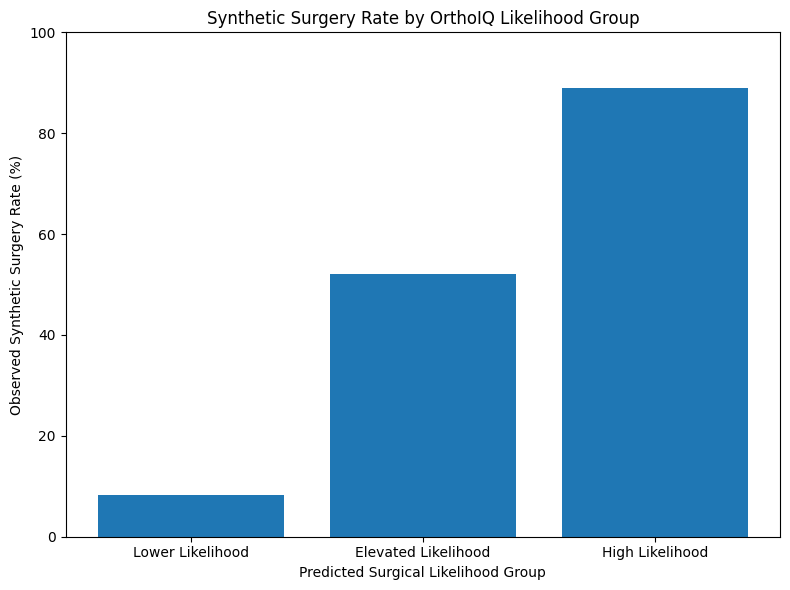

In [53]:
plt.figure(figsize=(8, 6))

plt.bar(
    likelihood_summary["Likelihood Group"],
    likelihood_summary["Observed Surgery Rate (%)"]
)

plt.title(
    "Synthetic Surgery Rate by OrthoIQ Likelihood Group"
)
plt.xlabel("Predicted Surgical Likelihood Group")
plt.ylabel("Observed Synthetic Surgery Rate (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Likelihood Stratification Interpretation

The OrthoIQ likelihood groups demonstrated a clear progression in synthetic surgical outcomes.

Patients classified in the Lower Likelihood group had an average predicted surgical likelihood of 9.4%, with an observed synthetic surgery rate of 8.3%.

The Elevated Likelihood group had an average predicted likelihood of 55.0%, with an observed synthetic surgery rate of 52.0%.

Patients in the High Likelihood group had an average predicted likelihood of 86.1%, with an observed synthetic surgery rate of 89.0%.

The increasing observed surgery rates across the three likelihood groups demonstrate that the Logistic Regression model effectively separated lower-likelihood patients from patients with progressively greater synthetic surgical likelihood.

The similarity between average predicted likelihood and observed synthetic surgery rates also demonstrates reasonable probability alignment within this simulated test population.

Because both the orthopedic clinical variables and surgical outcomes were synthetically generated, these results demonstrate model behavior within the simulation rather than real-world clinical predictive validity.

## Final Model Recommendation

Logistic Regression was selected as the preferred model for the OrthoIQ surgical-likelihood framework.

At the default 50% classification threshold, Logistic Regression achieved **85.8% accuracy**, **80.4% precision**, **80.4% recall** for the synthetic surgery class, and a **ROC-AUC of 0.936**. The model outperformed Random Forest, which achieved 83.0% accuracy, 76.1% surgery recall, and a ROC-AUC of 0.913.

Beyond stronger predictive performance, Logistic Regression provides greater interpretability. Model coefficients allow the direction and relative influence of patient characteristics to be examined, which is particularly valuable when communicating healthcare analytics results to clinical and operational stakeholders.

An exploratory **40% classification threshold** was also evaluated to examine a screening-oriented use case in which identifying more potential surgical patients is prioritized. Lowering the threshold from 50% to 40% increased surgery recall from **80.4% to 86.6%** and reduced false negatives from **131 to 90**. This improvement required accepting an increase in false positives from 131 to 184, while overall accuracy decreased only slightly from 85.8% to **85.1%**.

For OrthoIQ, the Logistic Regression model is therefore recommended as the primary analytical model, with predicted surgical likelihood used as a continuous measure rather than as an automated treatment decision. The Lower, Elevated, and High likelihood groups provide an additional way to translate model output into interpretable patient-stratification categories.

The 40% exploratory threshold and likelihood categories are analytical demonstrations only and should not be interpreted as clinically validated decision criteria.


## Limitations

Several important limitations should be considered when interpreting the OrthoIQ results.

### Synthetic Data

The source healthcare dataset is synthetic, and the orthopedic-specific variables used in this project were also synthetically generated. These include BMI, pain score, functional limitation, imaging severity, conservative treatment history, comorbidity burden, and the surgical outcome.

The project therefore represents a simulated orthopedic analytics environment rather than an analysis of actual patient records.

### Simulated Clinical Relationships

Clinical relationships were intentionally incorporated into the synthetic data-generation process. Functional limitation, imaging severity, and failed conservative treatment were designed to have the strongest relationship with surgical likelihood, while age and pain score contributed smaller effects. BMI and comorbidity burden were primarily modeled as surgical-candidacy modifiers.

Because the target was generated using predefined relationships and probabilistic variation, model performance primarily measures how effectively the machine-learning models recover patterns embedded within the simulation. The resulting coefficients and predictive metrics should not be interpreted as evidence of real-world clinical relationships or causation.

### Simplified Surgical Decision-Making

Actual orthopedic surgical decision-making involves substantially more information than is represented in OrthoIQ. Important factors may include the specific joint and diagnosis, radiographic grading, symptom duration, detailed conservative-treatment history, prior procedures, smoking status, frailty, medical contraindications, patient goals and preferences, surgeon judgment, and shared decision-making.

These factors were not available in the source dataset and were not incorporated into the current simulation.

### Validation and Generalizability

The model has not been trained or externally validated using real orthopedic patient populations or data from independent healthcare systems. The reported accuracy, recall, ROC-AUC, predicted likelihoods, and observed likelihood-group outcomes therefore apply only to this synthetic test population.

Although predicted likelihood and observed synthetic surgery rates showed reasonable alignment across the Lower, Elevated, and High likelihood groups, these results should not be interpreted as evidence of clinical calibration.

### Thresholds and Intended Use

The 40% exploratory classification threshold and the Lower, Elevated, and High likelihood categories were selected to demonstrate threshold optimization and patient stratification. They were not derived from clinical guidelines or validated patient outcomes.

OrthoIQ is an educational and portfolio analytics project. It should not be used to recommend surgery, determine surgical candidacy, prioritize actual patients, or replace evaluation and shared decision-making by qualified healthcare professionals.


## Conclusion

OrthoIQ demonstrates an end-to-end orthopedic healthcare analytics workflow that combines healthcare domain knowledge with data preparation, synthetic feature engineering, exploratory analysis, machine learning, model interpretation, and patient-level risk stratification.

Using a synthetic arthritis population, the project developed a classification framework for estimating synthetic surgical likelihood from age, BMI, pain score, functional limitation, imaging severity, conservative treatment history, and comorbidity burden.

Logistic Regression emerged as the preferred model, achieving **85.8% accuracy and a ROC-AUC of 0.936**, while identifying **80.4% of synthetic surgery cases** at the default 50% threshold. It also outperformed the more complex Random Forest model, demonstrating that increased model complexity does not necessarily result in better performance.

Threshold analysis further demonstrated the importance of evaluating predictive models according to their intended operational purpose. In the simulated screening scenario, lowering the classification threshold to 40% increased surgery recall to **86.6%** and reduced false negatives from **131 to 90**, while maintaining **85.1% overall accuracy**.

The project also translated individual predicted probabilities into Lower, Elevated, and High surgical-likelihood groups. Observed synthetic surgery rates increased from **8.3% in the Lower group to 52.0% in the Elevated group and 89.0% in the High group**, demonstrating clear separation across the model's patient-stratification categories.

The value of OrthoIQ is not the creation of a clinically validated surgical prediction tool. Rather, the project demonstrates how an orthopedic clinical question can be translated into a structured healthcare analytics problem, evaluated using appropriate machine-learning metrics, interpreted in the context of operational tradeoffs, and communicated with appropriate clinical limitations.

A future OrthoIQ version could extend this framework to real orthopedic EHR and procedural data containing validated diagnoses, imaging findings, conservative treatments, surgical procedures, and patient outcomes, followed by external validation and appropriate clinical governance.
